# Reproduction: Community-science flower color dataset & delayed flowering of red-flowering plants

**Paper:** McKenzie et al., *A massive community-science flower color dataset reveals convergent evolution of delayed flowering phenology in North American red-flowering plants*, bioRxiv 2024.09.25.614826 (v1, posted 2024-09-27). https://doi.org/10.1101/2024.09.25.614826

**Author code:** https://github.com/pmckenz1/flower_color_phenology @ commit `876d923e55b599cb940b3a26f207ddb58b420ec8`

**Scope (partial demonstration):** This notebook regenerates the observation-level dataset that the authors distribute as `2_fulldata_cleaned_matched_GPT_colors.csv` (too large for GitHub), by re-running their data-assembly notebooks 1 and 3, and then reproduces the **Figure 2A-style northern-edge flowering lag** analysis (`manuscript/figure_notebooks/fig_2a.ipynb`): the 80th-percentile latitude of each flower color through spring in the eastern U.S. (longitude −96 to −59), where red/orange plants' northern edge trails white and other colors.

**Omitted:** GPT-4V color labeling (retired model + API key), MaxEnt/WorldClim distribution modeling, TRY trait analyses, pollinator analyses — these need external software/data not bundled in the repository.

**実行内容（日本語）:** 著者のデータ結合ノートブック1・3を再実行して観察レベルの色ラベル付きデータセットを再生成し、論文Figure 2A相当の「東部アメリカにおける花色別の北限緯度の季節変化」解析を再現します。GPT-4Vラベリング、MaxEnt分布モデル、TRY形質解析は含みません。CPUランタイムのみ必要です（Runtime > Change runtime type で CPU を選択してください）。

## Runtime & environment check

This reproduction is pure pandas/numpy analysis of tabular data — no GPU and no model weights are required. We verify the core packages (all preinstalled in standard Colab) and their versions before downloading anything.

**環境チェック:** GPUは不要です。pandas・numpy・statsmodelsなど標準Colabにプリインストールされたライブラリのバージョンを確認します。

In [ ]:
import sys, platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels
from dateutil import parser as date_parser

print("Python:", sys.version.split()[0], "| platform:", platform.platform())
print("pandas:", pd.__version__, "| numpy:", np.__version__)
print("statsmodels:", statsmodels.__version__)

Python: 3.13.15 | platform: Linux-6.6.122+-x86_64-with-glibc2.39
pandas: 2.2.3 | numpy: 2.1.3
statsmodels: 0.15.0


## Step 1 — Acquire the pinned raw inputs (Colab-only download)

All inputs are git blobs (not LFS) in the author repository at the pinned commit. We download, inside this Colab VM only:

- the **12 raw iNaturalist export zips** (`raw_inaturalist_exports/observations-*.csv.zip`, ≈179 MB total; each ≤100 MB so raw.githubusercontent.com serves them directly),
- the **GPT taxon color table** `1_FULL_gpt_labeled_taxon.csv` (1.4 MB),
- the **hand-validated red-taxon list** `3_validated_FULL_gpt_labeled_REDS_ONLY.csv` (33 KB).

Source: `https://raw.githubusercontent.com/pmckenz1/flower_color_phenology/876d923e55b599cb940b3a26f207ddb58b420ec8/...`

**入力データのダウンロード:** 著者リポジトリ（コミット固定）から生のiNaturalistエクスポート12件とGPT花色テーブル2件を、このColab VM内にのみダウンロードします（合計約180MB）。

In [ ]:
import urllib.request, os

PIN = "876d923e55b599cb940b3a26f207ddb58b420ec8"
BASE = f"https://raw.githubusercontent.com/pmckenz1/flower_color_phenology/{PIN}"
DATA_DIR = "/content/inputs"
os.makedirs(DATA_DIR, exist_ok=True)

ZIP_IDS = [365581, 365660, 365693, 365710, 365727, 365743,
           365778, 365799, 365820, 365833, 365843, 366053]
FILES = ([f"raw_inaturalist_exports/observations-{i}.csv.zip" for i in ZIP_IDS]
         + ["manuscript/final_data/1_FULL_gpt_labeled_taxon.csv",
            "manuscript/final_data/3_validated_FULL_gpt_labeled_REDS_ONLY.csv"])

for rel in FILES:
    dest = os.path.join(DATA_DIR, os.path.basename(rel))
    if os.path.exists(dest) and os.path.getsize(dest) > 0:
        print(f"cached: {dest} ({os.path.getsize(dest):,} bytes)")
        continue
    url = f"{BASE}/{rel}"
    print("downloading", url, flush=True)
    urllib.request.urlretrieve(url, dest)   # bounded per-file GET, pinned commit URL
    print("  ->", f"{os.path.getsize(dest):,} bytes", flush=True)

downloading https://raw.githubusercontent.com/pmckenz1/flower_color_phenology/876d923e55b599cb940b3a26f207ddb58b420ec8/raw_inaturalist_exports/observations-365581.csv.zip


  -> 13,955,195 bytes


downloading https://raw.githubusercontent.com/pmckenz1/flower_color_phenology/876d923e55b599cb940b3a26f207ddb58b420ec8/raw_inaturalist_exports/observations-365660.csv.zip


  -> 18,280,681 bytes


downloading https://raw.githubusercontent.com/pmckenz1/flower_color_phenology/876d923e55b599cb940b3a26f207ddb58b420ec8/raw_inaturalist_exports/observations-365693.csv.zip


...

  -> 1,638,408 bytes


downloading https://raw.githubusercontent.com/pmckenz1/flower_color_phenology/876d923e55b599cb940b3a26f207ddb58b420ec8/manuscript/final_data/1_FULL_gpt_labeled_taxon.csv


  -> 1,395,412 bytes


downloading https://raw.githubusercontent.com/pmckenz1/flower_color_phenology/876d923e55b599cb940b3a26f207ddb58b420ec8/manuscript/final_data/3_validated_FULL_gpt_labeled_REDS_ONLY.csv


  -> 32,943 bytes


## Step 2 — Validate the downloaded bytes

Before scientific use we check: exactly 14 files present, every zip opens as a valid ZIP archive containing one observations CSV, the two CSVs parse, and the per-file observation counts match the counts the authors recorded in `raw_inaturalist_exports/README.txt` (e.g. 144,954 observations for export 365581).

**ダウンロード検証:** ZIPの整合性、CSVのパース可能性、著者がREADMEに記録した観察数との一致を確認します。

In [ ]:
import zipfile, csv, io

EXPECTED_OBS = {365581: 144954, 365660: 179888, 365693: 163644, 365710: 189486,
                365727: 178341, 365743: 197608, 365778: 116989, 365799: 160678,
                365820: 130972, 365833: 86908, 365843: 197846, 366053: 16486}

for i in ZIP_IDS:
    path = f"{DATA_DIR}/observations-{i}.csv.zip"
    assert os.path.getsize(path) > 1_000_000, f"suspiciously small zip: {path}"
    with zipfile.ZipFile(path) as zf:
        names = zf.namelist()
        assert len(names) == 1 and names[0].endswith(".csv"), names
    with zipfile.ZipFile(path) as zf:
        csv_name = zf.namelist()[0]
        with zf.open(csv_name) as fh:
            reader = csv.reader(io.TextIOWrapper(fh, "utf-8"))  # csv parser handles quoted newlines
            n = sum(1 for _ in reader) - 1   # data rows minus header
    # the authors' README quotes the export-queue counts; allow small drift
    ok = abs(n - EXPECTED_OBS[i]) <= max(0.005 * EXPECTED_OBS[i], 20)
    status = "OK" if ok else f"MISMATCH (expected {EXPECTED_OBS[i]})"
    print(f"observations-{i}.csv.zip: {n:,} data rows (author README: {EXPECTED_OBS[i]:,}) -> {status}")

coldf = pd.read_csv(f"{DATA_DIR}/1_FULL_gpt_labeled_taxon.csv")
reds = pd.read_csv(f"{DATA_DIR}/3_validated_FULL_gpt_labeled_REDS_ONLY.csv")
print("\nGPT taxon colors:", len(coldf), "rows, columns:", list(coldf.columns))
print("Validated reds:", len(reds), "rows, columns:", list(reds.columns))

observations-365581.csv.zip: 144,954 data rows (author README: 144,954) -> OK


observations-365660.csv.zip: 179,890 data rows (author README: 179,888) -> OK


observations-365693.csv.zip: 163,646 data rows (author README: 163,644) -> OK


observations-365710.csv.zip: 189,491 data rows (author README: 189,486) -> OK


observations-365727.csv.zip: 178,345 data rows (author README: 178,341) -> OK


...

observations-365799.csv.zip: 160,679 data rows (author README: 160,678) -> OK


observations-365820.csv.zip: 130,974 data rows (author README: 130,972) -> OK


observations-365833.csv.zip: 86,909 data rows (author README: 86,908) -> OK


observations-365843.csv.zip: 197,847 data rows (author README: 197,846) -> OK
observations-366053.csv.zip: 16,486 data rows (author README: 16,486) -> OK



GPT taxon colors: 13366 rows, columns: ['binomial', 'photo_url', 'flower_present', 'subjectivity', 'gpt_color']
Validated reds: 294 rows, columns: ['binomial', 'photo_url', 'flower_present', 'subjectivity', 'gpt_color', 'validated', 'comments']


## Step 3 — Notebook 1: merge the raw iNaturalist exports

This is a faithful re-execution of `manuscript/data_notebooks/1_merging_raw_iNat_exports.ipynb` (pinned commit): the 12 export zips are concatenated into the combined occurrence table `combined_raw_inaturalist_export.csv` under `/content`. Only the output directory differs from the authors' relative paths. Expected total ≈ 1.76 million observations (the README counts above).

**ノートブック1の再実行:** 12件のエクスポートを結合し、約176万観察の統合CSVを作成します（出力先を `/content` 配下に変更した以外は著者コードと同じ処理です）。

In [ ]:
raw_obs_directory = DATA_DIR
filenames = [f"observations-{i}.csv.zip" for i in ZIP_IDS]
file_paths = [os.path.join(raw_obs_directory, f) for f in filenames]
output_path = "/content/combined_raw_inaturalist_export.csv"

all_data = pd.DataFrame()
for file_path in file_paths:
    try:
        df = pd.read_csv(file_path, low_memory=False)
        all_data = pd.concat([all_data, df], ignore_index=True)
        print(f"{os.path.basename(file_path)}: {len(df):,} rows (running total {len(all_data):,})", flush=True)
    except Exception as e:
        print(f"{file_path}: {e}")

all_data.to_csv(output_path, index=False)
print("\ncolumns:", list(all_data.columns))
print("total observations:", f"{len(all_data):,}")

observations-365581.csv.zip: 144,954 rows (running total 144,954)


observations-365660.csv.zip: 179,890 rows (running total 324,844)


observations-365693.csv.zip: 163,646 rows (running total 488,490)


observations-365710.csv.zip: 189,491 rows (running total 677,981)


observations-365727.csv.zip: 178,345 rows (running total 856,326)


...

observations-365820.csv.zip: 130,974 rows (running total 1,462,579)


observations-365833.csv.zip: 86,909 rows (running total 1,549,488)


observations-365843.csv.zip: 197,847 rows (running total 1,747,335)


observations-366053.csv.zip: 16,486 rows (running total 1,763,821)



columns: ['id', 'observed_on_string', 'observed_on', 'time_observed_at', 'time_zone', 'user_id', 'user_login', 'user_name', 'created_at', 'updated_at', 'quality_grade', 'license', 'url', 'image_url', 'sound_url', 'tag_list', 'description', 'num_identification_agreements', 'num_identification_disagreements', 'captive_cultivated', 'oauth_application_id', 'place_guess', 'latitude', 'longitude', 'positional_accuracy', 'private_place_guess', 'private_latitude', 'private_longitude', 'public_positional_accuracy', 'geoprivacy', 'taxon_geoprivacy', 'coordinates_obscured', 'positioning_method', 'positioning_device', 'species_guess', 'scientific_name', 'common_name', 'iconic_taxon_name', 'taxon_id']
total observations: 1,763,821


## Step 3b — Input preview: geographic coverage

Before the analysis, a human-readable preview of the actual merged input. The authors show a toyplot scatter of a 5,000-observation random subsample (`1_merging_raw_iNat_exports.ipynb`); we render the same subsample with matplotlib, colored by longitude to show the west→east export windows. This is a preview of real input data, not a scientific result.

**入力プレビュー:** 結合済みデータから5,000件を無作為抽出し、緯度経度を散布図で表示します（著者のtoyplot図をmatplotlibで置き換えた診断的プレビューです）。

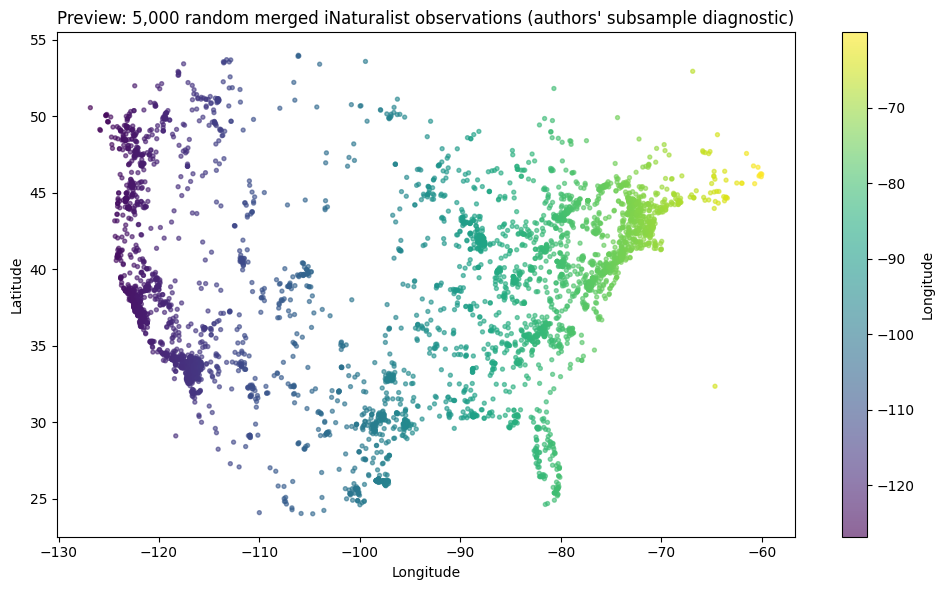

subsample extent: lon -126.8303375242 to -60.001025 | lat 24.0234957437 to 53.97111533


In [ ]:
subsample = all_data.sample(5000, random_state=0)
plt.figure(figsize=(10, 6))
sc = plt.scatter(subsample.longitude, subsample.latitude, c=subsample.longitude,
                 cmap="viridis", s=8, alpha=0.6)
plt.colorbar(sc, label="Longitude")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Preview: 5,000 random merged iNaturalist observations (authors' subsample diagnostic)")
plt.tight_layout()
plt.savefig("/content/input_preview_map.png", dpi=120, bbox_inches="tight")
plt.show()
print("subsample extent: lon", subsample.longitude.min(), "to", subsample.longitude.max(),
      "| lat", subsample.latitude.min(), "to", subsample.latitude.max())

## Step 4 — Notebook 3: match GPT taxon colors to observations

Faithful re-execution of `manuscript/data_notebooks/3_merge_GPT_taxon_colors_with_observations.ipynb`: each observation's binomial is matched to the GPT color table; when a species has several color labels the author picks one at random — we seed numpy's RNG (`np.random.seed(0)`) here for reproducibility, an explicit, documented adaptation of the author's unseeded `np.random.choice`. Observations without a color label, `unknown` colors, hybrids (`x`/`×` in the name) and single-word scientific names are dropped, then `day_of_year` is added. The author's per-row `dateutil.parser.parse` is replaced by the vectorized `pd.to_datetime(...).dt.dayofyear` (identical result for these ISO dates).

**ノートブック3の再実行:** 観察データにGPT花色を割り当て、交雑種・単名・色なしを除去し、day_of_year列を追加します（乱数シード0の追加と日付処理のベクトル化のみが文書化済みの変更です）。

In [ ]:
inatdata = pd.read_csv(output_path, low_memory=False)
coldf = pd.read_csv(f"{DATA_DIR}/1_FULL_gpt_labeled_taxon.csv")
print("observations:", f"{len(inatdata):,}", "| color table:", f"{len(coldf):,}")

inatdata["binomial"] = [" ".join(str(i).split()[:2]) for i in inatdata.scientific_name]

np.random.seed(0)  # documented adaptation: author used unseeded np.random.choice
color_lookup = {b: np.array(g) for b, g in coldf.groupby("binomial").gpt_color}

color_list = []
for obs_sp in inatdata.binomial:
    colors = color_lookup.get(obs_sp)
    color_list.append(np.random.choice(colors).lower() if colors is not None else np.nan)
inatdata["color"] = color_list

inatdata_plus_color = inatdata[~inatdata.color.isna()]
print("with any color label:", f"{len(inatdata_plus_color):,}")

inatdata_plus_color = inatdata_plus_color[~inatdata_plus_color.color.eq("nan")]
inatdata_plus_color = inatdata_plus_color[~inatdata_plus_color.color.eq("unknown")]
print("after removing nan/unknown colors:", f"{len(inatdata_plus_color):,}")

hybrid_mask = ~np.array(["x" in str(i).split() for i in inatdata_plus_color.scientific_name])
print("dropping 'x' hybrids:", int((~hybrid_mask).sum()))
inatdata_plus_color = inatdata_plus_color[hybrid_mask]

hybrid_mask = ~np.array(["×" in str(i).split() for i in inatdata_plus_color.scientific_name])
print("dropping '×' hybrids:", int((~hybrid_mask).sum()))
inatdata_plus_color = inatdata_plus_color[hybrid_mask]

single_names_mask = ~np.array([len(str(i).split()) == 1 for i in inatdata_plus_color.scientific_name])
print("dropping single-word names:", int((~single_names_mask).sum()))
inatdata_plus_color = inatdata_plus_color[single_names_mask]
print("final rows before day_of_year:", f"{len(inatdata_plus_color):,}")

inatdata_plus_color = inatdata_plus_color.copy()
inatdata_plus_color["day_of_year"] = pd.to_datetime(
    inatdata_plus_color.observed_on, errors="coerce").dt.dayofyear
n_bad = int(inatdata_plus_color.day_of_year.isna().sum())
print("unparseable observed_on dates:", n_bad)
inatdata_plus_color = inatdata_plus_color.dropna(subset=["day_of_year"])
print("final matched dataset:", f"{len(inatdata_plus_color):,}")

observations: 1,763,821 | color table: 13,366


with any color label: 1,758,467


after removing nan/unknown colors: 1,675,324


dropping 'x' hybrids: 1


dropping '×' hybrids: 354


dropping single-word names: 0


final rows before day_of_year: 1,674,969


unparseable observed_on dates: 0


final matched dataset: 1,674,969


## Step 5 — Screen red labels with the hand-validation list

Exactly as in the authors' `fig_2a.ipynb`: species marked `validated == "no"` in `3_validated_FULL_gpt_labeled_REDS_ONLY.csv` (GPT had called them red but the authors' manual check disagreed) get their color set to NaN and are dropped, so that the red/orange lines reflect validated red-flowering taxa only.

**赤色ラベルの検証:** 著者の目視検証で「赤ではない」と判定された種を除外します（`fig_2a.ipynb` と同じ処理）。

In [ ]:
reds = pd.read_csv(f"{DATA_DIR}/3_validated_FULL_gpt_labeled_REDS_ONLY.csv")
num_in_red_labels = sum(dat_binomial := inatdata_plus_color["binomial"].isin(reds["binomial"]))
truereds = reds[reds["validated"] == "yes"]["binomial"]
num_in_red_true = sum(inatdata_plus_color["binomial"].isin(truereds))
print(f"observations of taxa in the red-validation list: {num_in_red_labels:,}")
print(f"observations of confirmed-red taxa: {num_in_red_true:,}")

not_red_sp = reds[reds["validated"] == "no"]["binomial"]
dat = inatdata_plus_color.copy()
dat.loc[dat["binomial"].isin(not_red_sp), "color"] = np.nan
dat = dat.dropna(subset=["color"])
print("observations after validation screen:", f"{len(dat):,}")
print("color distribution:\n", dat.color.value_counts())

observations of taxa in the red-validation list: 40,742
observations of confirmed-red taxa: 38,840


observations after validation screen: 1,673,067
color distribution:
 color
white     490992
yellow    322183
purple    274890
pink      274307
blue       81965
green      70457
orange     69266
red        38840
brown      28520
maroon     21647
Name: count, dtype: int64


## Step 6 — Figure 2A core calculation: northern-edge latitude per color

The authors' method (`fig_2a.ipynb`, final-figure cell), with identical parameters: observations binned into longitude −96..−59 (eastern U.S.), then for each color and each 15-day sliding window from day 1 to day 200, the **80th percentile of latitude** of that color's observations is recorded — the "northern edge" of the color's range in spring. The resulting series is smoothed with LOWESS (`frac=0.2`). Colors: red, orange, white, and all seven other colors lumped as a grey comparison group.

**Figure 2Aの中核計算:** 東部アメリカ（経度−96〜−59）で、各色について15日幅のスライディングウィンドウごとに緯度の80パーセンタイル（北限）を求め、LOWESS（frac=0.2）で平滑化します。パラメータは著者コードと同一です。

In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess

percentile_threshold = 0.8
window_size = 15
max_day = 200  # limited to first part of year
lon_range = "-96 to -59"

dat["lon_window"] = pd.cut(dat["longitude"], bins=[-130, -96, -59],
                           labels=["-130 to -96", "-96 to -59"], include_lowest=True)

def calculate_percentiles(dat, color_filter, lon_range, window_size, percentile_threshold, max_day):
    subdf = dat[color_filter]
    subdf = subdf[subdf["lon_window"] == lon_range]
    percentiles = []
    for day in range(1, max_day - window_size + 1):
        day_range = np.arange(day, day + window_size)
        window_df = subdf[subdf["day_of_year"].isin(day_range)]
        if len(window_df) > 0:
            percentiles.append(np.percentile(window_df["latitude"], percentile_threshold * 100))
        else:
            percentiles.append(np.nan)
    return percentiles

red_filter = dat["color"] == "red"
orange_filter = dat["color"] == "orange"
white_filter = dat["color"] == "white"
non_red_orange_filter = ~dat["color"].isin(["red", "orange"])

percentiles_red = calculate_percentiles(dat, red_filter, lon_range, window_size, percentile_threshold, max_day)
percentiles_orange = calculate_percentiles(dat, orange_filter, lon_range, window_size, percentile_threshold, max_day)
percentiles_white = calculate_percentiles(dat, white_filter, lon_range, window_size, percentile_threshold, max_day)
percentiles_non_red_orange = calculate_percentiles(dat, non_red_orange_filter, lon_range, window_size, percentile_threshold, max_day)
print("computed northern-edge series; red days with data:", int(np.sum(~np.isnan(percentiles_red))), "of", len(percentiles_red))

computed northern-edge series; red days with data: 185 of 185


## Step 7 — Reproduce the Figure 2A plot

The authors' final figure (their third plotting cell, saved as `leading_edge_east.pdf` in the repository): red and orange trail black (white) and the grey lumped non-red/non-orange colors to lower latitudes through spring — the delayed flowering phenology of red-flowering plants. We plot with the same LOWESS smoothing, axis limits (x 1–185, y 27–50), and colors, and additionally save a PNG. The rendered figure below is this run's actual output from the regenerated dataset.

**Figure 2Aの再現描画:** 著者と同じ平滑化・軸範囲・配色で描画し、PNGとして保存します。以下の図が本実行の実際の出力です。

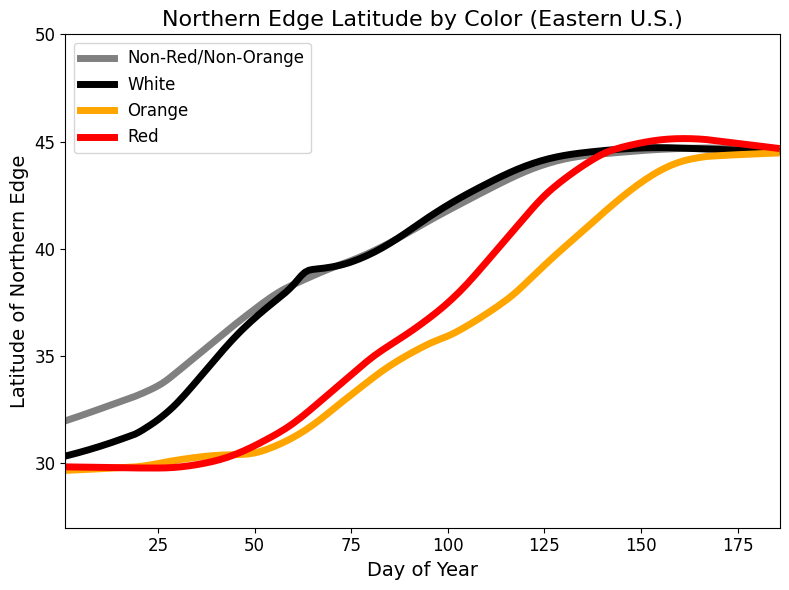

saved: /content/fig2a_northern_edge_east.png


In [ ]:
x = np.arange(1, max_day - window_size + 1)

plt.figure(figsize=(8, 6))

lowess_non_red_orange = lowess(np.array(percentiles_non_red_orange), x, frac=0.2)
plt.plot(lowess_non_red_orange[:, 0], lowess_non_red_orange[:, 1], label="Non-Red/Non-Orange", color="grey", linewidth=5)

lowess_white = lowess(np.array(percentiles_white), x, frac=0.2)
plt.plot(lowess_white[:, 0], lowess_white[:, 1], label="White", color="black", linewidth=5)

lowess_orange = lowess(np.array(percentiles_orange), x, frac=0.2)
plt.plot(lowess_orange[:, 0], lowess_orange[:, 1], label="Orange", color="orange", linewidth=5)

lowess_red = lowess(np.array(percentiles_red), x, frac=0.2)
plt.plot(lowess_red[:, 0], lowess_red[:, 1], label="Red", color="red", linewidth=5)

plt.title("Northern Edge Latitude by Color (Eastern U.S.)", fontsize=16)
plt.xlabel("Day of Year", fontsize=14)
plt.ylabel("Latitude of Northern Edge", fontsize=14)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend(fontsize=12)
plt.ylim([27, 50])
plt.xlim([1, max_day - window_size + 1])
plt.tight_layout()
plt.savefig("/content/fig2a_northern_edge_east.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved: /content/fig2a_northern_edge_east.png")

## Step 8 — Quantitative summary of the flowering lag

The paper's Figure 2B reports that white flowers precede red flowers by ~25.5 days on average across the eastern U.S. As a plausibility check on our regenerated dataset (not a re-derivation of that statistic's exact estimator), we report the day-of-year at which each color's smoothed northern edge first reaches 40°N, plus a small exportable table of the smoothed series.

**定量サマリー:** 再生データの妥当性確認として、平滑化された北限が緯度40°に初めて達する日を色別に報告し、CSVへ書き出します。

In [ ]:
def first_day_at_lat(ys, target=40.0):
    for day, y in zip(x, ys):
        if np.isfinite(y) and y >= target:
            return day
    return None

summary = []
for name, series in [("red", percentiles_red), ("orange", percentiles_orange),
                     ("white", percentiles_white), ("non-red/non-orange", percentiles_non_red_orange)]:
    sm = lowess(np.array(series), x, frac=0.2)
    summary.append({"color": name, "first_day_north_of_40N": first_day_at_lat(sm[:, 1]),
                    "mean_northern_edge_lat_days_60_150": float(np.nanmean(series[59:150]))})
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

out_df = pd.DataFrame({"day_of_year": x,
                       "red": percentiles_red, "orange": percentiles_orange,
                       "white": percentiles_white, "non_red_orange": percentiles_non_red_orange})
out_df.to_csv("/content/fig2a_northern_edge_series.csv", index=False)
print("saved: /content/fig2a_northern_edge_series.csv")

             color  first_day_north_of_40N  mean_northern_edge_lat_days_60_150
               red                     113                           38.767111
            orange                     130                           36.791897
             white                      83                           42.161037
non-red/non-orange                      82                           42.022009
saved: /content/fig2a_northern_edge_series.csv


## Interpretation and validation record

**What was executed:** the full data-assembly path (merge 12 raw iNaturalist exports → match GPT taxon colors → validation screen) and the Figure 2A northern-edge analysis, from the authors' pinned commit `876d923e`, on a single CPU Colab runtime, with all data downloaded inside this Colab VM.

**Expected pattern:** red and orange northern edges stay at lower latitudes than white and other colors through most of days 1–185 in the eastern U.S. — the paper's convergent delayed-flowering result (Fig. 2A). The paper reports red flowers start flowering 20–50 days later in the eastern U.S.; if your figure shows red/orange lines below the grey/white lines, the regeneration succeeded.

**Adaptations (documented):** numpy seed 0 for the author's random color choice; vectorized `pd.to_datetime` for `day_of_year`; matplotlib instead of toyplot for the preview; PNG output at 150 dpi. No scientific parameters were changed.

**Not verified here:** GPT-4V labeling itself, MaxEnt/pollinator/TRY analyses, and dataset-level statistics beyond this single eastern-U.S. figure. A one-run regeneration is not verification of the paper's full results.

**検証記録（日本語）:** 著者コミット固定のコードに基づき、生データ結合からFigure 2A相当の解析までをCPUランタイムで実行しました。乱数シード追加などの変更は文書化済みです。GPT-4VラベリングやMaxEnt等の解析は含まれず、単一図の再現は論文全体の検証ではありません。

**References:** bioRxiv 2024.09.25.614826; github.com/pmckenz1/flower_color_phenology (data_notebooks 1 & 3, figure_notebooks/fig_2a.ipynb).